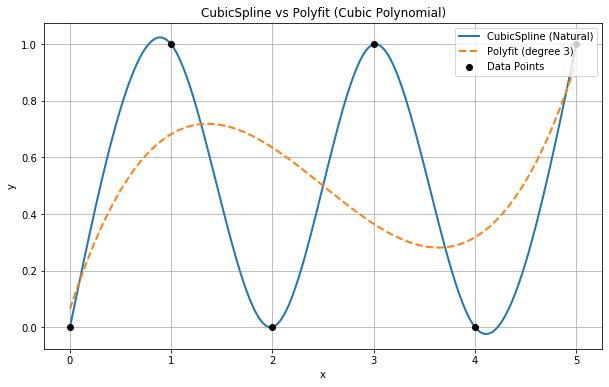

=== Error Comparison ===
Spline MSE: 0.000000
Polyfit MSE: 0.169312
Spline R²: 1.000000
Polyfit R²: 0.322751


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Known data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

# ---- Cubic Spline ----
cs = CubicSpline(x, y, bc_type='natural')
x_interp = np.linspace(0, 5, 300)
y_spline = cs(x_interp)

# ---- Polynomial Fit (degree 3) ----
degree = 3
coeffs = np.polyfit(x, y, degree)
poly = np.poly1d(coeffs)
y_poly = poly(x_interp)

# ---- Plotting ----
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Data Points', zorder=3)

plt.plot(x_interp, y_spline, label='CubicSpline (Natural)', linewidth=2)
plt.plot(x_interp, y_poly, label=f'Polyfit (degree {degree})', linestyle='--', linewidth=2)

plt.title("CubicSpline vs Polyfit (Cubic Polynomial)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# ---- Error Metrics ----
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

# Evaluate at original data points
y_spline_at_x = cs(x)
y_poly_at_x = poly(x)

print("=== Error Comparison ===")
print(f"Spline MSE: {mse(y, y_spline_at_x):.6f}")
print(f"Polyfit MSE: {mse(y, y_poly_at_x):.6f}")
print(f"Spline R²: {r2(y, y_spline_at_x):.6f}")
print(f"Polyfit R²: {r2(y, y_poly_at_x):.6f}")